In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv.zip to dataset.csv.zip


In [2]:
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost

In [4]:
import pandas as pd
import zipfile
import io

# Assuming 'dataset.csv.zip' was uploaded and its content is in the 'uploaded' dictionary
# First, extract the content of the zip file
with zipfile.ZipFile(io.BytesIO(uploaded['dataset.csv.zip']), 'r') as z:
    z.extractall()

df = pd.read_csv("dataset.csv")

df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
timestamp,0
crypto_name,0
date,0


In [6]:
df = df.dropna()

In [7]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [8]:
df['volatility'] = (df['high'] - df['low']) / df['close']

In [9]:
df['returns'] = df['close'].pct_change()

In [10]:
df['MA7'] = df['close'].rolling(7).mean()
df['MA30'] = df['close'].rolling(30).mean()

In [11]:
df['rolling_volatility'] = df['returns'].rolling(7).std()

In [12]:
df['liquidity_ratio'] = df['volume'] / df['marketCap']

In [13]:
df = df.dropna()

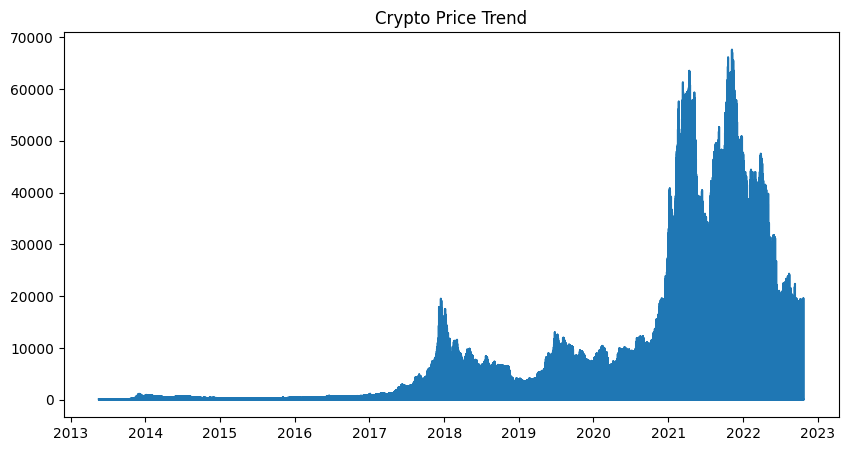

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['date'], df['close'])
plt.title("Crypto Price Trend")
plt.show()

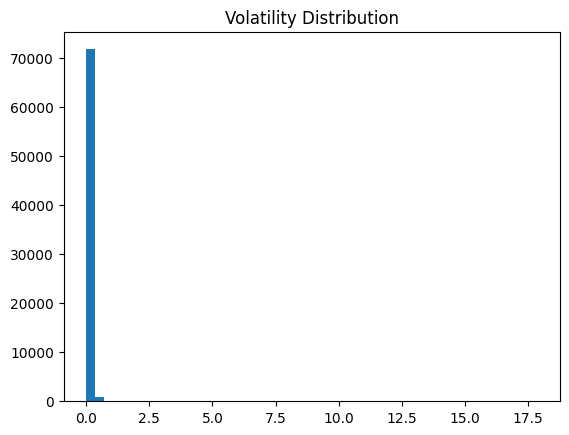

In [15]:
plt.hist(df['volatility'], bins=50)
plt.title("Volatility Distribution")
plt.show()

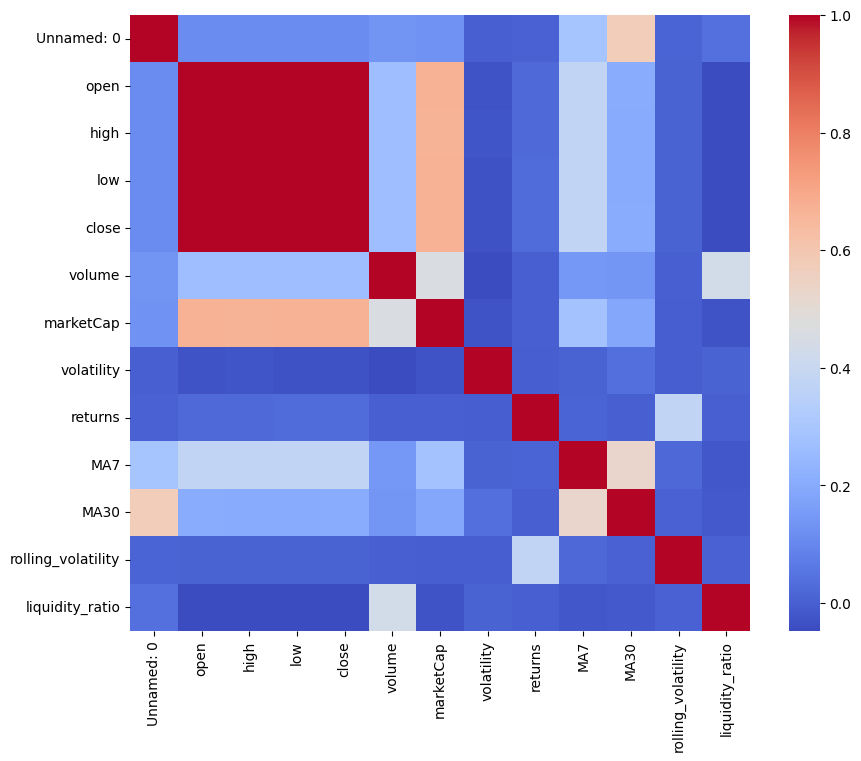

In [17]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.show()

In [18]:
features = [
'open','high','low','close',
'volume','marketCap',
'MA7','MA30',
'rolling_volatility',
'liquidity_ratio'
]

X = df[features]

y = df['volatility']

In [19]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,shuffle=False
)

In [21]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# Identify rows in X_train that contain infinite values
inf_mask = X_train.isin([np.inf, -np.inf]).any(axis=1)

# Filter X_train and y_train to exclude rows with infinite values
# Using .copy() to avoid potential SettingWithCopyWarning
X_train_filtered = X_train[~inf_mask].copy()
y_train_filtered = y_train[~inf_mask].copy()

model = RandomForestRegressor(n_estimators=100)

model.fit(X_train_filtered, y_train_filtered)

RandomForestRegressor()

In [24]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import numpy as np

# Identify rows in X_test that contain infinite values
inf_mask_test = X_test.isin([np.inf, -np.inf]).any(axis=1)

# Filter X_test and y_test to exclude rows with infinite values
X_test_filtered = X_test[~inf_mask_test].copy()
y_test_filtered = y_test[~inf_mask_test].copy()

pred = model.predict(X_test_filtered)

rmse = np.sqrt(mean_squared_error(y_test_filtered,pred))
mae = mean_absolute_error(y_test_filtered,pred)
r2 = r2_score(y_test_filtered,pred)

print("RMSE:",rmse)
print("MAE:",mae)
print("R2:",r2)

RMSE: 0.14387833470776715
MAE: 0.03938190006260004
R2: 0.20051943076969747


In [25]:
import joblib

joblib.dump(model,"crypto_volatility_model.pkl")

['crypto_volatility_model.pkl']

In [26]:
files.download("crypto_volatility_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>